In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow import keras
import os
from tensorflow.keras import layers, models

# Load model terbaik

In [22]:
keras_input = layers.Input(shape=(128, 128, 3))
x = layers.Conv2D(64, 3, padding="same", activation="relu", name="conv_1")(keras_input)
x = layers.AveragePooling2D(2)(x)
x = layers.Conv2D(128, 3, padding="same", activation="relu", name="conv_2")(x)
x = layers.AveragePooling2D(2)(x)
x = layers.Conv2D(256, 3, padding="same", activation="relu", name="conv_3_last")(x)
x = layers.AveragePooling2D(2)(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x)
keras_output = layers.Dense(6, activation="softmax")(x)
model = models.Model(inputs=keras_input, outputs=keras_output)

weights_path = os.path.abspath("saved_models/model_14_L3_F64_K3_avg.weights.h5")
if os.path.exists(weights_path):
    model.load_weights(weights_path)
    print("Bobot model berhasil dimuat.")
else:
    print(f"Peringatan: Bobot {weights_path} tidak ditemukan!")

Bobot model berhasil dimuat.


# Persiapan

Found 3000 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step

Label Asli: street
Prediksi Model: street


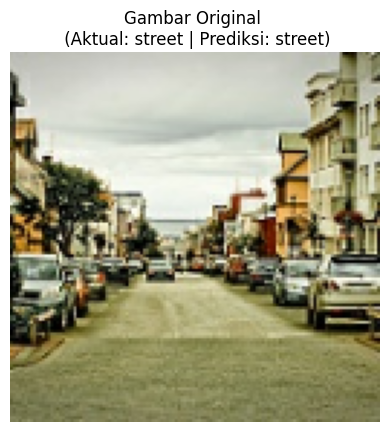

In [24]:
np.random.seed(67)
TEST_PATH = os.path.abspath("../../data/1_cnn_image_classification/seg_test/seg_test")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH, image_size=(128, 128), batch_size=1, shuffle=True, label_mode="categorical"
)

class_names = test_dataset.class_names
for images, labels in test_dataset:
    img_raw = images[0].numpy()
    img_scaled = images / 255.0  
    true_label = class_names[np.argmax(labels[0].numpy())]
    break

preds = model.predict(img_scaled)
pred_label = class_names[np.argmax(preds)]
print(f"\nLabel Asli: {true_label}")
print(f"Prediksi Model: {pred_label}")

plt.imshow(img_raw.astype("uint8"))
plt.title(f"Gambar Original \n (Aktual: {true_label} | Prediksi: {pred_label})")
plt.axis('off')
plt.show()

# Fungsi untuk Grad-Cam

In [29]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_raw, heatmap, pred_label, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img_raw.shape[1], img_raw.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)
    superimposed_img = jet_heatmap * alpha + img_raw
    superimposed_img = keras.utils.array_to_img(superimposed_img)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img_raw.astype("uint8"))
    ax[0].set_title("Original Image")
    ax[0].axis('off')
    ax[1].imshow(superimposed_img)
    ax[1].set_title("Grad-CAM Heatmap")
    ax[1].axis('off')

    plt.suptitle(f"Analisis Keputusan Model (Prediksi: {pred_label})")
    plt.show()

# Implementasi

C:\Users\user\AppData\Local\Temp\ipykernel_14588\2029423828.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


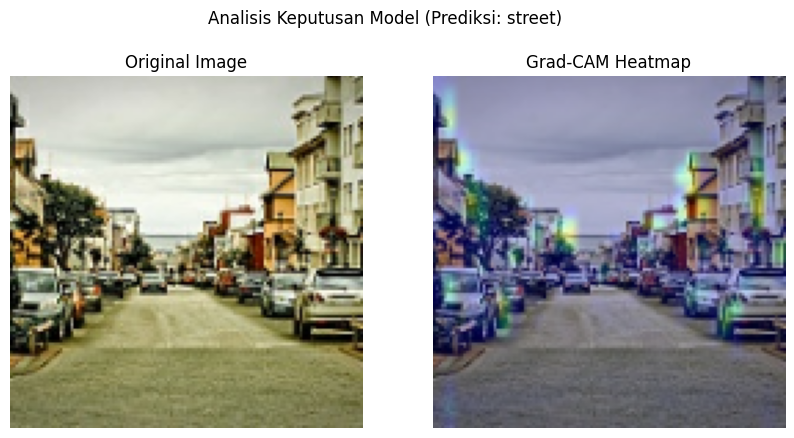

In [30]:
last_conv_layer_name = "conv_3_last"
heatmap = make_gradcam_heatmap(img_scaled, model, last_conv_layer_name)
display_gradcam(img_raw, heatmap, pred_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step


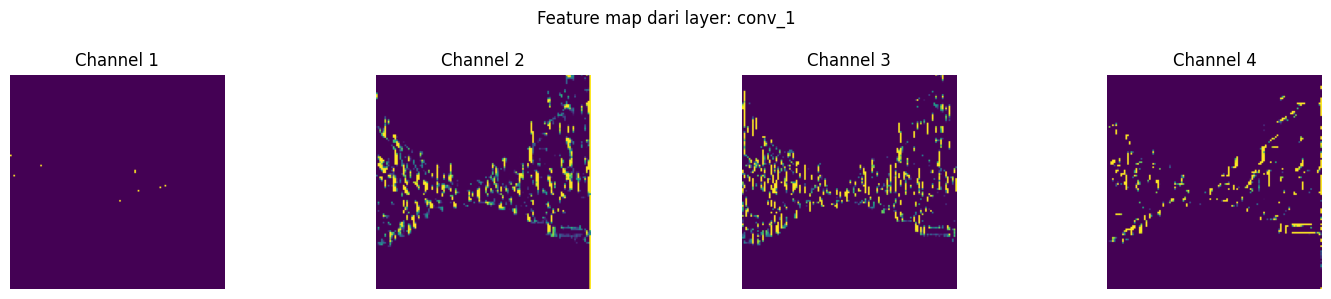

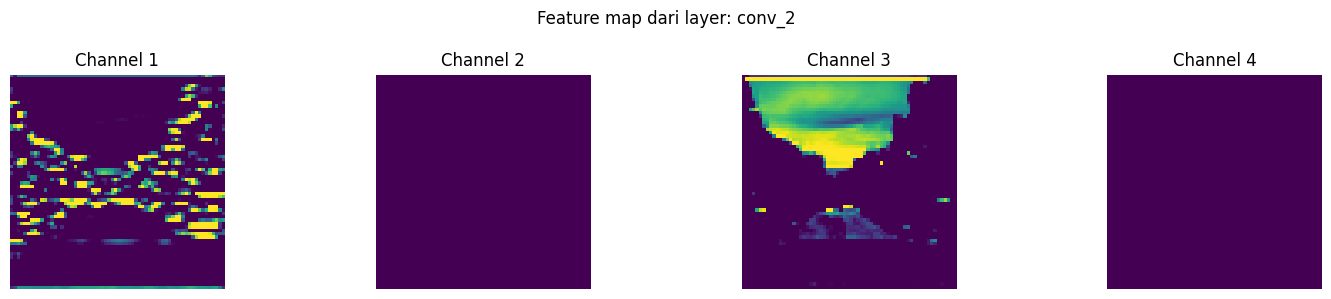

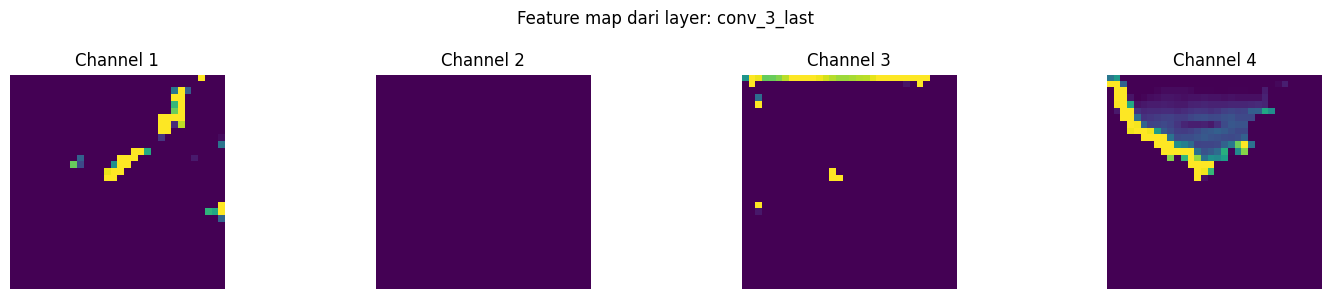

In [32]:
layer_names = ['conv_1', 'conv_2', 'conv_3_last']
layer_outputs = [model.get_layer(name).output for name in layer_names]
activation_model = models.Model(inputs=model.inputs, outputs=layer_outputs)
activations = activation_model.predict(img_scaled)
images_per_row = 4

for layer_name, layer_activation in zip(layer_names, activations):
    fig, axes = plt.subplots(1, images_per_row, figsize=(15, 3))
    fig.suptitle(f'Feature map dari layer: {layer_name}')
    
    for col in range(images_per_row):
        channel_image = layer_activation[0, :, :, col]
        channel_image -= channel_image.mean()
        if channel_image.std() > 0:
            channel_image /= channel_image.std()
        channel_image *= 64
        channel_image += 128
        channel_image = np.clip(channel_image, 0, 255).astype('uint8')

        ax = axes[col]
        ax.imshow(channel_image, cmap='viridis')
        ax.axis('off')
        ax.set_title(f'Channel {col+1}')
        
    plt.tight_layout()
    plt.show()